In [1]:
# Set up the proper working directory

import os

current_dir = os.getcwd()
if current_dir.split('/')[-1] == 'notebooks':
    os.chdir('..')

print("Current working directory:", os.getcwd())

Current working directory: /mnt/e/Google Drive/Scolaire/Mines/ue53-NLP/projet/arrayxtract


In [2]:
from scripts.utils import *
from scripts.data_preprocessing import preprocess_PDF2Images
from scripts.dataset import ArreysDetectDataset

import numpy as np
import os
import matplotlib.pyplot as plt
import json

from torch.utils.data import DataLoader

import re

%load_ext autoreload
%autoreload 2

In [5]:
# ## Uncomment if file waas 

# filename = '1999-12-21_AP_initial'
# exists = False

# # Check that the file exists in the data folder
# for file in os.listdir('data/images/dpi100'):
#     if filename in file:
#         print('File found:', file)
#         exists = True
#         break

# filenames = []
# for file in os.listdir('data/images/dpi100'):
#     if filename in file:
#         filenames.append(file.split('.')[0])

# # Build set with pages from the PDF
# pages_set = ArreysDetectDataset('data/', filenames, train=False, inference=True)
# pages_loader = DataLoader(pages_set, batch_size=8, shuffle=False)

File found: 1999-12-21_AP_initial_p1.jpg


In [4]:
preprocess_PDF2Images(dpi=100, input_folder='data/inference')
pdf_filenames = []
for pdf_filename in os.listdir('data/inference') :
    if pdf_filename.endswith('pdf') :
        pdf_filenames.append(pdf_filename.split('.')[0])

filenames = []
for file in os.listdir('data/images/dpi100'):
    for pdf_filename in pdf_filenames :
        if pdf_filename in file:
            filenames.append(file.split('.')[0])
# Build set with pages from the PDF
pages_set = ArreysDetectDataset('data/', filenames, train=False, inference=True)
pages_loader = DataLoader(pages_set, batch_size=5, shuffle=False)

Converted 12 pages to JPG images. --- 3%


In [5]:
from scripts.models import get_model_object_detection

from torchvision.models.detection import fasterrcnn_mobilenet_v3_large_fpn, fasterrcnn_resnet50_fpn_v2
import torch

model = get_model_object_detection(fasterrcnn_resnet50_fpn_v2(trainable_backbone_layers=2), 2)
model.load_state_dict(torch.load('models/fasterrcnn_resnet50_fpn_v2_model.pth'))

/home/user/miniconda3/envs/pytorch_env/lib/python3.10/site-packages/torchvision/models/detection/backbone_utils.py:162: UserWarning: Changing trainable_backbone_layers has no effect if neither pretrained nor pretrained_backbone have been set to True, falling back to trainable_backbone_layers=5 so that all layers are trainable
  warnings.warn(
/tmp/ipykernel_757/3632572772.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the use

<All keys matched successfully>

/home/user/miniconda3/envs/pytorch_env/lib/python3.10/site-packages/torchvision/utils.py:211: UserWarning: boxes doesn't contain any box. No box was drawn
  warnings.warn("boxes doesn't contain any box. No box was drawn")


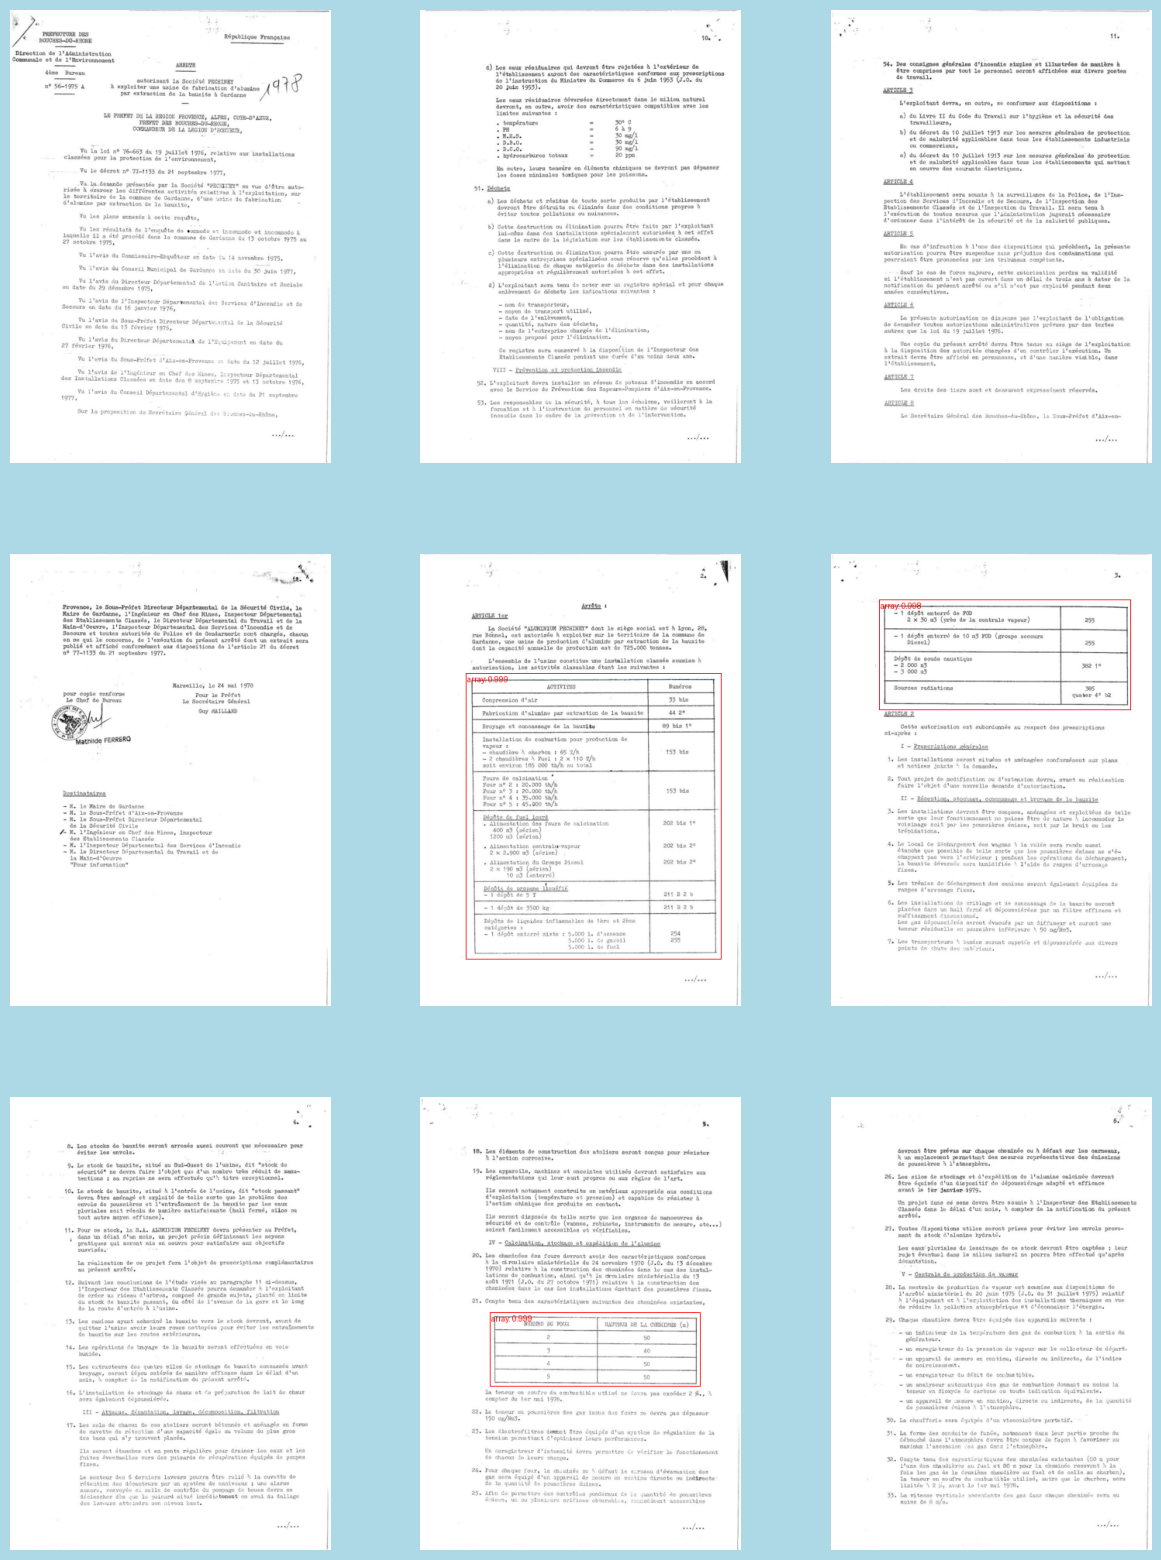

In [6]:
import matplotlib.pyplot as plt

from torchvision.utils import draw_bounding_boxes
from torchvision.ops import nms

root = 'dataset/images/dpi100/'
device = get_device()

model.eval()
model.to(device)

total_predictions = []

with torch.no_grad():
    for images in pages_loader:
        x = [image.to(device) for image in images]
        predictions = model(x)
        total_predictions += predictions

fig, axs = plt.subplots(3, 3, figsize=(15, 20))
fig.patch.set_facecolor('lightblue')

for i in range(9):
    idx = i
    pred = total_predictions[idx]
    image = pages_set.__getitem__(idx)
    pred_labels = [f"array: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
    pred_scores = pred["scores"]
    pred_boxes = pred["boxes"]
    keep_indices = torch.arange(len(pred_scores)).to(device)
    keep_indices = nms(pred_boxes, pred_scores, 0.05)
    keep_indices = keep_indices[pred_scores[keep_indices] > 0.9]
    pred_boxes = pred_boxes[keep_indices]
    pred_labels = [pred_labels[i] for i in keep_indices]
    #image = T.Resize((585, 414))(x[i])

    output_image = draw_bounding_boxes(image, pred_boxes, pred_labels, colors="red")
    axs[i // 3, i % 3].imshow(output_image.permute(1, 2, 0))
    axs[i // 3, i % 3].axis('off')
    

In [8]:
from PIL import Image

output = {}

i_tab = 1

for i, pred in enumerate(total_predictions) :

    image = Image.open(f'data/images/dpi100/{filenames[i]}.jpg')
    image_np = np.array(image)
    pred_labels = [f"array: {score:.3f}" for label, score in zip(pred["labels"], pred["scores"])]
    pred_scores = pred["scores"]
    pred_boxes = pred["boxes"]
    keep_indices = torch.arange(len(pred_scores)).to(device)
    keep_indices = nms(pred_boxes, pred_scores, 0.05)
    keep_indices = keep_indices[pred_scores[keep_indices] > 0.9]
    pred_boxes = pred_boxes[keep_indices]
    pred_labels = [pred_labels[i] for i in keep_indices]

    for box in pred_boxes:
        xt, yt, xb, yb = box.int().tolist()
        xt, yt, xb, yb = xt/414, yt/585, xb/414, yb/585
        output[f'tableau {i_tab}'] = {'top': yt, 'bottom': yb, 'page_number' : i}
        xt, xb = int(xt * image_np.shape[1]), int(xb * image_np.shape[1])
        yt, yb = int(yt * image_np.shape[0]), int(yb * image_np.shape[0])
        array = image_np[yt:yb, xt:xb]
        # array = ((array - array.min()) * 255 / (array.max() - array.min())).astype(np.uint8)
        array = Image.fromarray(array)
        array.save(f'data/inference/output/array_{i_tab}.png')
        xt, yt, xb, yb = xt/414, yt/585, xb/414, yb/585
        output[f'tableau {i_tab}'] = {'top': yt, 'bottom': yb, 'page_number' : i}
        i_tab += 1

In [9]:
with open('data/inference/output/output.json', 'w') as f:
    json.dump(output, f)